In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib import cm
from scipy.spatial import KDTree
from mpl_toolkits.axes_grid1 import make_axes_locatable

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..'))) 
from src import *

## check plot read and sampling

In [2]:
im,final_data = read_stemo21_selfunc()
PIX,Q,csamp,nq,npix = sample_stemo_selfunc(final_data)
interp = get_interp_selfunc()

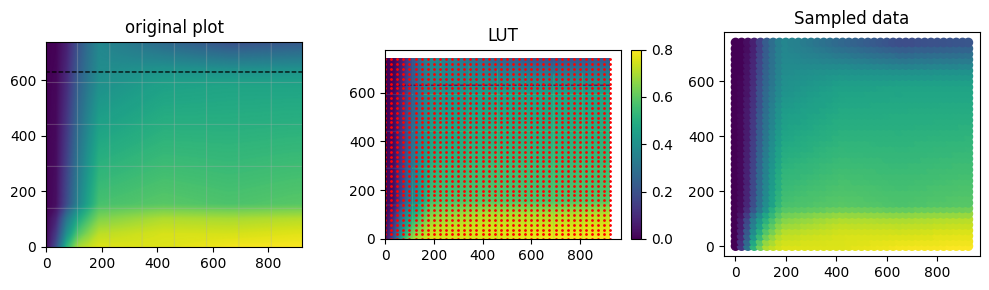

In [4]:
fig,ax = plt.subplots(1,3,figsize=(10,3))

ax[0].imshow(im,origin='lower')
ax[0].set_title("original plot")

im1 = ax[1].imshow(final_data,vmax=0.8,origin='lower')
ax[1].set_title("LUT")
div1 = make_axes_locatable(ax[1])
cax1 = div1.append_axes('right',0.1,pad=0.1)
# plot sampling grid
[ax[1].scatter(x,y,s=1,c='r') for x,y in zip(PIX,Q)]

# plot sampled points
[ax[2].scatter(x,y,c=c,cmap='viridis',vmax=0.8) for x,y,c in zip(PIX,Q,csamp)]
ax[2].set_title("Sampled data")

fig.colorbar(im1,cax=cax1,shrink=0.5)
fig.tight_layout();

## check interpolation

''

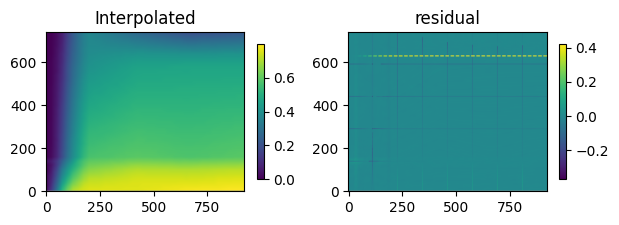

In [9]:
# inverse x,y here (compare to paper) bc imshow flips it?
X,Y = np.meshgrid(np.arange(nq),np.arange(npix))
interp_ = get_interp_selfunc()
iq = nq/100
ipix = npix/200
Z = interp_(X/iq,Y/ipix)
# plot
fig,ax = plt.subplots(1,2)
im0=ax[0].imshow(Z.T,origin='lower')
im1=ax[1].imshow(Z.T-final_data,origin='lower')

ax[0].set_title("Interpolated")
ax[1].set_title("residual")
[fig.colorbar(i,shrink=0.3) for i in [im0,im1]]
fig.tight_layout()
;

## use for some survey resolution

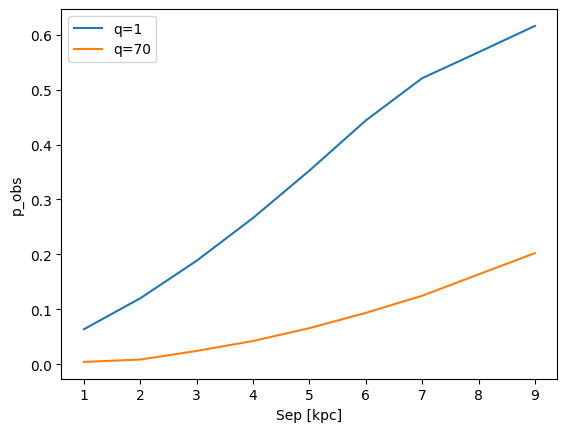

In [5]:
seps = np.arange(1,10)
pobs_ez = psel(seps,0.2,1)
pobs_hard = psel(seps,0.2,70)
plt.plot(seps,pobs_ez,label='q=1')
plt.plot(seps,pobs_hard,label='q=70')
plt.xlabel("Sep [kpc]")
plt.ylabel("p_obs")
plt.legend();